# Amblyopia & Strabismus Detection Pipeline: Setup and Data Verification

In [4]:
import os
import sys
import pandas as pd

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Define paths
CSV_PATH = '/content/drive/MyDrive/eye_dataset/Image_Summary_With_Embedded_Images1(Cropped Results).csv'
IMG_DIR = '/content/drive/MyDrive/eye_dataset/images/'
SAVE_DIR = '/content/drive/MyDrive/eye_dataset/'

print(f"CSV Path: {CSV_PATH}")
print(f"Image Directory: {IMG_DIR}")
print(f"Save Directory: {SAVE_DIR}")
print("\n--- Verifying Paths ---")

# Verify CSV file existence
if os.path.exists(CSV_PATH):
    print(f"[PASS] CSV file found at: {CSV_PATH}")
else:
    print(f"[FAIL] CSV file NOT found at: {CSV_PATH}. Please check the path and ensure your Google Drive is mounted correctly.")
    sys.exit("CSV file not found. Exiting.")

# Verify Image Directory existence and list contents
if os.path.exists(IMG_DIR):
    print(f"[PASS] Image directory found at: {IMG_DIR}")
    print("Listing first 10 image files:")
    image_files = [f for f in os.listdir(IMG_DIR) if os.path.isfile(os.path.join(IMG_DIR, f))]
    if image_files:
        for f in image_files[:10]:
            print(f"  - {f}")
        if len(image_files) > 10:
            print(f"  ...and {len(image_files) - 10} more files.")
    else:
        print("  No image files found in the directory.")
else:
    print(f"[FAIL] Image directory NOT found at: {IMG_DIR}. Please create the directory or check the path.")

# Verify Save Directory existence and list contents
os.makedirs(SAVE_DIR, exist_ok=True) # Ensure SAVE_DIR exists
if os.path.exists(SAVE_DIR):
    print(f"[PASS] Save directory found/created at: {SAVE_DIR}")
    print("Listing contents of save directory:")
    save_dir_contents = os.listdir(SAVE_DIR)
    if save_dir_contents:
        for item in save_dir_contents:
            print(f"  - {item}")
    else:
        print("  Save directory is empty.")
else:
    print(f"[FAIL] Save directory NOT found/created at: {SAVE_DIR}. Something went wrong.")

print("\n--- Path verification complete ---")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV Path: /content/drive/MyDrive/eye_dataset/Image_Summary_With_Embedded_Images1(Cropped Results).csv
Image Directory: /content/drive/MyDrive/eye_dataset/images/
Save Directory: /content/drive/MyDrive/eye_dataset/

--- Verifying Paths ---
[PASS] CSV file found at: /content/drive/MyDrive/eye_dataset/Image_Summary_With_Embedded_Images1(Cropped Results).csv
[FAIL] Image directory NOT found at: /content/drive/MyDrive/eye_dataset/images/. Please create the directory or check the path.
[PASS] Save directory found/created at: /content/drive/MyDrive/eye_dataset/
Listing contents of save directory:
  - Image_Summary_With_Embedded_Images1(Cropped Results).csv
  - sample_grid.png
  - eye_model_final.h5

--- Path verification complete ---


# CELL 1: Install Libraries, Import Packages, and Configuration

In [3]:
# Install required library
!pip install tensorflowjs

# Import necessary libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import re
import json
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# Define paths (re-defined here to ensure cell self-containment for library installs)
CSV_PATH = '/content/drive/MyDrive/eye_dataset/Image_Summary_With_Embedded_Images1(Cropped Results).csv'
IMG_DIR = '/content/drive/MyDrive/eye_dataset/images/'
SAVE_DIR = '/content/drive/MyDrive/eye_dataset/'
os.makedirs(SAVE_DIR, exist_ok=True) # Ensure SAVE_DIR exists

# Check GPU availability
print(f"\nTensorFlow version: {tf.__version__}")
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Training will run on CPU, which may be slower.')
else:
  print('Found GPU at: {}'.format(device_name))

# Set seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Reproducibility seed set to: {SEED}")


TensorFlow version: 2.19.0
GPU device not found. Training will run on CPU, which may be slower.
Reproducibility seed set to: 42


# CELL 2: Load CSV Data and Extract Image Filenames

In [ ]:
# Robust local/Colab dataset loader for the embedded-image CSV
import os
import re
from pathlib import Path
import pandas as pd

# --- Paths (works on Colab + local) ---
_LOCAL_CSV = Path("/home/anandhu/projects/amblyopia-main/amblyopia-main/Image_Summary_With_Embedded_Images1(Cropped Results).csv")
_COLAB_CSV = Path("/content/drive/MyDrive/eye_dataset/Image_Summary_With_Embedded_Images1(Cropped Results).csv")

CSV_PATH = str(_LOCAL_CSV if _LOCAL_CSV.exists() else _COLAB_CSV)

# Try common image dirs near the CSV when local
csv_dir = Path(CSV_PATH).parent
candidate_img_dirs = [
    csv_dir / "images",
    csv_dir / "Images",
    csv_dir / "cropped",
    csv_dir / "Cropped",
    csv_dir,
]
IMG_DIR = next((str(p) + "/" for p in candidate_img_dirs if p.exists() and p.is_dir()), str(csv_dir) + "/")

print("Loading CSV:", CSV_PATH)
print("Using image dir:", IMG_DIR)

# --- CSV read: tolerate messy rows + embedded newlines in quoted fields ---
df = pd.read_csv(
    CSV_PATH,
    encoding="latin1",
    engine="python",
    sep=",",
    quotechar='"',
    skip_blank_lines=True,
    on_bad_lines="skip",
)

# Normalize column names
_df_cols = [str(c).strip() for c in df.columns]
df.columns = _df_cols

# Drop fully empty rows and rows missing the first column
first_col = df.columns[0]
df = df.dropna(how="all")
df = df.dropna(subset=[first_col])

# Ensure expected columns exist
for col in ["Original File", "Cropped Eye Image", "Text in Image", "EYE", "AGE", "SEX", "CR ( DEGREE )", "PCT/ MKT IN PD"]:
    if col not in df.columns:
        df[col] = None

# --- Fix the dataset's main issue ---
# Many rows are malformed like: "PHOTO-...jpg      eye_1.jpg" (missing comma),
# so the cropped filename ends up stuck inside "Original File".
# We recover:
# - Original File: keep the first .jpg-like token
# - Cropped Eye Image: extract eye_\d+.jpg-like token
img_pat = re.compile(r"(?i)\beye_\d+\.(jpg|jpeg|png)\b")
orig_pat = re.compile(r"(?i).+?\.(jpg|jpeg|png)")

orig_raw = df["Original File"].astype(str)

# Extract cropped image name from anywhere in the raw string
cropped_from_orig = orig_raw.apply(lambda s: (img_pat.search(s).group(0) if img_pat.search(s) else None))

# Extract original photo name (first image-like token)
original_photo = orig_raw.apply(lambda s: (orig_pat.search(s).group(0).strip() if orig_pat.search(s) else s.strip()))

# If Cropped Eye Image column is empty, fill it from parsed value
cropped_col = df["Cropped Eye Image"]
if cropped_col.isna().mean() > 0.8:
    df["Cropped Eye Image"] = cropped_from_orig

# Always clean up Original File to be the original photo filename
# (not "photo + cropped" glued together)
df["Original File"] = original_photo

# Canonical image file column used downstream
# Prefer the cropped eye filename if present, else fall back to parsed eye_*.jpg in Original File
image_file = df["Cropped Eye Image"].astype(str)
image_file = image_file.where(~df["Cropped Eye Image"].isna(), cropped_from_orig)
df["image_file"] = image_file

# Clean up whitespace and normalize
for c in ["Original File", "Cropped Eye Image", "image_file", "EYE", "SEX"]:
    df[c] = df[c].astype(str).str.strip().replace({"nan": None, "None": None, "": None})

# Basic sanity checks
print("Dataset shape:", df.shape)
print("Rows with image_file:", df["image_file"].notna().sum(), "/", len(df))
print("Unique image_file:", df["image_file"].nunique())

# Show a few recovered filenames
display(df[["Original File", "Cropped Eye Image", "image_file", "EYE", "AGE", "SEX"]].head(10))


In [ ]:
# Output folder: keep ALL artifacts together (dataset copy, images, models, plots)
from datetime import datetime
import json
import shutil

RUN_ROOT = Path("/home/anandhu/projects/amblyopia-main/amblyopia-main/eye_runs")
RUN_ID = datetime.now().strftime("run-%Y%m%d-%H%M%S")
RUN_DIR = RUN_ROOT / RUN_ID
ART_DIR = RUN_DIR / "artifacts"
IMG_OUT_DIR = RUN_DIR / "images"
MODEL_DIR = RUN_DIR / "models"
REPORT_DIR = RUN_DIR / "reports"

for p in [RUN_ROOT, RUN_DIR, ART_DIR, IMG_OUT_DIR, MODEL_DIR, REPORT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Make downstream cells (that use SAVE_DIR) write into this run folder
SAVE_DIR = str(RUN_DIR)
print("Run folder:", RUN_DIR)

# Save cleaned dataframe snapshot
clean_csv = ART_DIR / "cleaned_dataset.csv"
df.to_csv(clean_csv, index=False)
print("Saved cleaned dataset:", clean_csv)

# Copy original CSV for reproducibility
try:
    shutil.copy2(CSV_PATH, ART_DIR / Path(CSV_PATH).name)
    print("Copied source CSV into run folder")
except Exception as exc:
    print("Could not copy source CSV:", exc)

# Verify images exist and (optionally) copy them into the run folder
# Produces a manifest of found/missing files.

# Candidate image roots (local repo sometimes stores images elsewhere)
img_roots = [
    Path(IMG_DIR),
    Path("/home/anandhu/projects/amblyopia-main/amblyopia-main/et_doctor_review_pack/images"),
]

# Expected image filenames
expected = [x for x in df["image_file"].dropna().astype(str).tolist() if x.strip()]
expected = sorted(set(expected))

_eye_pat = re.compile(r"(?i)^eye_(\d+)\.(jpg|jpeg|png)$")

def resolve_image_path(fname: str):
    """Return (src_path, src_root, resolved_note) or (None, None, reason)."""
    fname = str(fname).strip()
    if not fname:
        return None, None, "empty"

    # 1) Direct filename lookup
    for root in img_roots:
        p = root / fname
        if p.exists() and p.is_file():
            return p, root, "exact"

    # 2) Common mismatch: CSV says eye_1.jpg but files are eye_000001.jpg
    m = _eye_pat.match(fname)
    if m:
        num = int(m.group(1))
        for ext in ("jpg", "jpeg", "png"):
            alt = f"eye_{num:06d}.{ext}"
            for root in img_roots:
                p = root / alt
                if p.exists() and p.is_file():
                    return p, root, f"padded:{alt}"

    return None, None, "not_found"

resolved_map = {}  # expected_name -> {src, note}
missing = []
for fname in expected:
    src, root, note = resolve_image_path(fname)
    if src is not None:
        resolved_map[fname] = {"src": str(src), "note": note, "root": str(root)}
    else:
        missing.append(fname)

existing = sorted(resolved_map.keys())

manifest = {
    "csv_path": CSV_PATH,
    "img_dir_requested": IMG_DIR,
    "img_roots_checked": [str(p) for p in img_roots],
    "run_dir": str(RUN_DIR),
    "expected_images": len(expected),
    "found_images": len(existing),
    "missing_images": len(missing),
    "missing_sample": missing[:25],
    "resolved_sample": {k: resolved_map[k] for k in existing[:10]},
}
(ART_DIR / "image_manifest.json").write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(json.dumps({k: manifest[k] for k in ["expected_images", "found_images", "missing_images"]}, indent=2))

if len(existing) == 0:
    print("\nSTOP: No matching images were found, so training cannot run.")
    print("Action: Put your cropped images (e.g. eye_1.jpg, eye_2.jpg, ...) into one of these folders:")
    for r in img_roots:
        print(" ", r)
    print("Then re-run from the loader cell onward.")
else:
    # Copy images into run folder for a fully self-contained run directory
    # Always copy into IMG_OUT_DIR using the *expected* filename.
    for fname, meta in resolved_map.items():
        src = Path(meta["src"])
        dst = IMG_OUT_DIR / fname
        if not dst.exists():
            shutil.copy2(src, dst)
    print(f"Copied {len(existing)} images into: {IMG_OUT_DIR}")


In [ ]:
# Model training + selection (runs only if images are present)
# Trains multiple transfer-learning backbones, selects best by macro-F1 on validation, saves everything into RUN_DIR.
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

if ("missing" in globals() and len(missing) > 0 and len(existing) == 0):
    print("Training skipped: images missing.")
else:
    # --- Prefer running off the copied, self-contained image folder ---
    IMG_DIR = str(IMG_OUT_DIR) + "/"

    # --- Hyperparams ---
    IMG_SIZE = (224, 224)
    BATCH = 32
    EPOCHS_1 = 12
    EPOCHS_2 = 8
    SEED = 42

    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    # --- Label mapping (already defined earlier in notebook; keep consistent) ---
    label_map = {"Normal": 0, "XT": 1, "ET": 2, "HT": 3}
    class_names = list(label_map.keys())

    # --- Load images into arrays (simple, deterministic) ---
    import cv2

    def read_image(path):
        img = cv2.imread(str(path))
        if img is None:
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        return img

    # Ensure diagnosis exists
    if "diagnosis" not in df.columns:
        raise RuntimeError("Missing df['diagnosis']. Run label parsing cell first.")

    rows = df.dropna(subset=["image_file", "diagnosis"]).copy()
    rows["diagnosis"] = rows["diagnosis"].astype(str).str.strip()

    X_list, y_list, keep_idx = [], [], []
    for i, r in rows.iterrows():
        fname = str(r["image_file"]).strip()
        if not fname:
            continue
        p = Path(IMG_DIR) / fname
        img = read_image(p)
        if img is None:
            continue
        lab = label_map.get(str(r["diagnosis"]).strip(), 0)
        X_list.append(img)
        y_list.append(lab)
        keep_idx.append(i)

    X = np.array(X_list, dtype=np.float32) / 255.0
    y = np.array(y_list, dtype=np.int64)

    print("Loaded images:", X.shape, "labels:", np.bincount(y, minlength=len(label_map)))

    # Save the subset of df that actually had images
    used_df = rows.loc[keep_idx].copy()
    used_df.to_csv(ART_DIR / "used_rows_with_images.csv", index=False)

    # --- Train/val/test split (stratified) ---
    from sklearn.model_selection import train_test_split

    X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
    X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=SEED)

    np.save(ART_DIR / "X_train.npy", X_train)
    np.save(ART_DIR / "y_train.npy", y_train)
    np.save(ART_DIR / "X_val.npy", X_val)
    np.save(ART_DIR / "y_val.npy", y_val)
    np.save(ART_DIR / "X_test.npy", X_test)
    np.save(ART_DIR / "y_test.npy", y_test)

    # --- Helper: build a classifier on top of a backbone ---
    def build_model(backbone_name: str):
        inp = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

        if backbone_name == "MobileNetV2":
            base = tf.keras.applications.MobileNetV2(include_top=False, weights="imagenet", input_tensor=inp)
            preprocess = tf.keras.applications.mobilenet_v2.preprocess_input
        elif backbone_name == "EfficientNetB0":
            base = tf.keras.applications.EfficientNetB0(include_top=False, weights="imagenet", input_tensor=inp)
            preprocess = tf.keras.applications.efficientnet.preprocess_input
        elif backbone_name == "ResNet50":
            base = tf.keras.applications.ResNet50(include_top=False, weights="imagenet", input_tensor=inp)
            preprocess = tf.keras.applications.resnet.preprocess_input
        else:
            raise ValueError(backbone_name)

        x = layers.Lambda(preprocess, name="preprocess")(inp)
        x = base(x)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dropout(0.35)(x)
        x = layers.Dense(256, activation="relu")(x)
        x = layers.Dropout(0.25)(x)
        out = layers.Dense(len(label_map), activation="softmax")(x)

        model = tf.keras.Model(inp, out, name=f"eye_{backbone_name}")
        return model, base

    def train_one(backbone_name: str):
        model, base = build_model(backbone_name)
        base.trainable = False

        ckpt = MODEL_DIR / f"{backbone_name}.best.keras"

        cbs = [
            callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
            callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
            callbacks.ModelCheckpoint(ckpt, monitor="val_loss", save_best_only=True),
        ]

        model.compile(
            optimizer=optimizers.Adam(1e-4),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"],
        )

        h1 = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS_1,
            batch_size=BATCH,
            verbose=1,
            callbacks=cbs,
        )

        # Fine-tune last block
        base.trainable = True
        for layer in base.layers[:-25]:
            layer.trainable = False
        model.compile(optimizer=optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        h2 = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=EPOCHS_2,
            batch_size=BATCH,
            verbose=1,
            callbacks=cbs,
        )

        # Eval on val
        val_probs = model.predict(X_val, batch_size=BATCH)
        val_pred = np.argmax(val_probs, axis=1)
        val_f1 = f1_score(y_val, val_pred, average="macro")
        val_acc = accuracy_score(y_val, val_pred)

        # Save training curves
        def save_curves(h, suffix):
            plt.figure(figsize=(10,4))
            plt.subplot(1,2,1)
            plt.plot(h.history.get("accuracy", []), label="train")
            plt.plot(h.history.get("val_accuracy", []), label="val")
            plt.title(f"{backbone_name} acc ({suffix})")
            plt.legend()
            plt.subplot(1,2,2)
            plt.plot(h.history.get("loss", []), label="train")
            plt.plot(h.history.get("val_loss", []), label="val")
            plt.title(f"{backbone_name} loss ({suffix})")
            plt.legend()
            outp = REPORT_DIR / f"{backbone_name}.curves.{suffix}.png"
            plt.tight_layout()
            plt.savefig(outp)
            plt.close()
            return str(outp)

        c1 = save_curves(h1, "phase1")
        c2 = save_curves(h2, "finetune")

        metrics = {
            "backbone": backbone_name,
            "val_macro_f1": float(val_f1),
            "val_accuracy": float(val_acc),
            "curves": {"phase1": c1, "finetune": c2},
            "best_checkpoint": str(ckpt),
        }
        (ART_DIR / f"metrics.{backbone_name}.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
        return model, metrics

    candidates = ["MobileNetV2", "EfficientNetB0", "ResNet50"]
    results = []
    models_by_name = {}

    for name in candidates:
        print("\n=== Training:", name, "===")
        m, met = train_one(name)
        results.append(met)
        models_by_name[name] = m

    # Select best by validation macro-F1
    best = sorted(results, key=lambda r: r["val_macro_f1"], reverse=True)[0]
    best_name = best["backbone"]
    best_model = models_by_name[best_name]

    print("\nBest model by val macro-F1:", best_name, best["val_macro_f1"])

    # Final test evaluation
    test_probs = best_model.predict(X_test, batch_size=BATCH)
    test_pred = np.argmax(test_probs, axis=1)

    report = classification_report(y_test, test_pred, target_names=class_names, output_dict=True)
    cm = confusion_matrix(y_test, test_pred)

    (ART_DIR / "best_model_selection.json").write_text(json.dumps({
        "best_backbone": best_name,
        "best_val_macro_f1": best["val_macro_f1"],
        "all": results,
    }, indent=2), encoding="utf-8")

    (ART_DIR / f"classification_report.{best_name}.json").write_text(json.dumps(report, indent=2), encoding="utf-8")

    # Confusion matrix plot
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.title(f"Confusion Matrix ({best_name})")
    cm_path = REPORT_DIR / f"confusion_matrix.{best_name}.png"
    plt.tight_layout()
    plt.savefig(cm_path)
    plt.close()

    # Save final model
    final_path = MODEL_DIR / f"best_model.{best_name}.keras"
    best_model.save(final_path)

    print("Saved best model:", final_path)
    print("Saved confusion matrix:", cm_path)
    print("All artifacts stored under:", RUN_DIR)


In [4]:
print(f"Loading CSV from: {CSV_PATH}")
df = pd.read_csv(CSV_PATH, encoding='latin1')

# Strip whitespace from all column names
df.columns = df.columns.str.strip()
print(f"Initial Dataset Shape: {df.shape}")
print("Original Columns (before stripping whitespace):")
# Display original columns (if any need to be checked before stripping, this would be a step before the above line)
# For now, just show the stripped ones
print(df.columns.tolist())

# Drop rows where 'Original File' is NaN
df_original_rows = len(df)
df = df.dropna(subset=['Original File']).reset_index(drop=True)
print(f"Dropped {df_original_rows - len(df)} rows with NaN in 'Original File'. New shape: {df.shape}")

# Extract image filename from 'Original File' using regex
# The pattern looks for 'eye_N' followed by an image extension
image_filename_pattern = r'eye_\d+\.(jpg|jpeg|png)'

def extract_image_name(text):
    if pd.isna(text): return None
    match = re.search(image_filename_pattern, str(text), re.IGNORECASE)
    return match.group(0) if match else None

df['image_file'] = df['Original File'].apply(extract_image_name)

print("\nDataset Head (first 5 rows):")
display(df.head(5))

valid_image_files = df['image_file'].notna().sum()
print(f"\nNumber of rows with valid 'image_file' values: {valid_image_files}/{len(df)}")
print(f"Number of unique extracted image filenames: {df['image_file'].nunique()}")
print("Data types after loading and processing:")
print(df.dtypes)

Loading CSV from: /content/drive/MyDrive/eye_dataset/Image_Summary_With_Embedded_Images1(Cropped Results).csv
Initial Dataset Shape: (4213, 25)
Original Columns (before stripping whitespace):
['Original File', 'Cropped Eye Image', 'Unnamed: 2', 'Unnamed: 3', 'Text in Image', 'EYE', 'AGE', 'SEX', 'CR ( DEGREE )', 'PCT/ MKT IN PD', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24']
Dropped 3510 rows with NaN in 'Original File'. New shape: (703, 25)

Dataset Head (first 5 rows):


,Original File,Cropped Eye Image,Unnamed: 2,Unnamed: 3,Text in Image,EYE,AGE,SEX,CR ( DEGREE ),PCT/ MKT IN PD,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,image_file
0,PHOTO-2024-11-28-18-16-12.jpg eye_1.jpg,NaN,NaN,NaN,RE XT\n 32 yrs/Male\nCR: 35 deg XT\nMKT: >50p...,RE,32.0,M,35.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eye_1.jpg
1,PHOTO-2024-12-04-18-41-16 2.jpg eye_2.jpg,NaN,NaN,NaN,9/M LE XT\n CR- LE 15 deg XT \n PCT 40 PD XT,LE,9.0,M,15.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eye_2.jpg
2,PHOTO-2024-12-04-18-41-16.jpg eye_3.jpg,NaN,NaN,NaN,31/M BE ET\n CR- RE 20 deg ET \n\nPCT - 45 PD...,BE,31.0,M,15.0,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eye_3.jpg
3,PHOTO-2024-12-06-18-31-25.jpg eye_4.jpg,NaN,NaN,NaN,CR-RE 30 DEG ET\n 9yrs/M \n\nRE ET PCT- 55 PD...,RE,9.0,M,30.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eye_4.jpg
4,PHOTO-2024-12-06-18-31-26 2.jpg eye_5.jpg,NaN,NaN,NaN,\n67yrs/M\n\n\nRE HT / RE XT\n\n\nCR- 15 DEG H...,RE,67.0,M,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,eye_5.jpg



Number of rows with valid 'image_file' values: 703/703
Number of unique extracted image filenames: 703
Data types after loading and processing:
Original File         object
Cropped Eye Image    float64
Unnamed: 2           float64
Unnamed: 3           float64
Text in Image         object
EYE                   object
AGE                  float64
SEX                   object
CR ( DEGREE )        float64
PCT/ MKT IN PD       float64
Unnamed: 10          float64
Unnamed: 11          float64
Unnamed: 12          float64
Unnamed: 13          float64
Unnamed: 14          float64
Unnamed: 15          float64
Unnamed: 16          float64
Unnamed: 17          float64
Unnamed: 18          float64
Unnamed: 19          float64
Unnamed: 20          float64
Unnamed: 21          float64
Unnamed: 22          float64
Unnamed: 23          float64
Unnamed: 24          float64
image_file            object
dtype: object


# CELL 3: Parse Labels and Analyze Distribution

Diagnosis Class Distribution:
diagnosis
XT        438
ET        225
Normal     23
HT         17
Name: count, dtype: int64

Risk Level Distribution:
risk
mild        353
moderate    222
urgent      105
normal       23
Name: count, dtype: int64


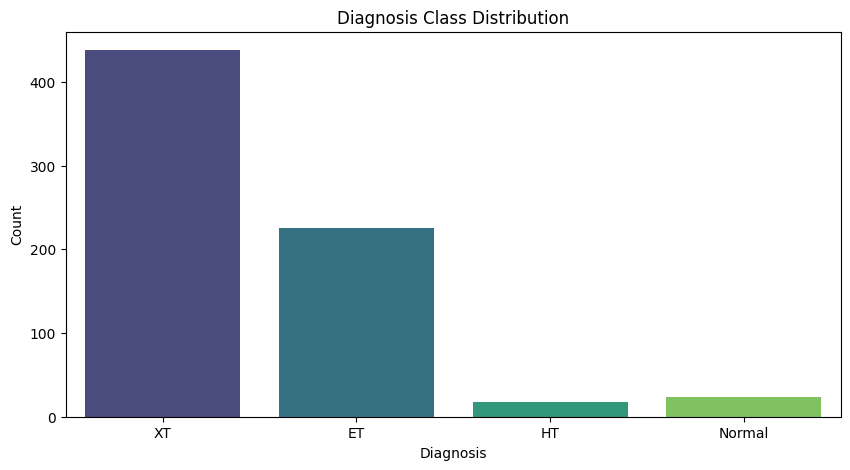

In [5]:
def extract_diagnosis(text):
    if pd.isna(text): return 'Normal'
    text = str(text).upper()
    if 'XT' in text: return 'XT'
    if 'ET' in text: return 'ET'
    if 'HT' in text or 'HYPER' in text: return 'HT'
    return 'Normal'

def extract_pd(text):
    if pd.isna(text): return 0.0
    match = re.search(r'(\d+)', str(text))
    return float(match.group(1)) if match else 0.0

def assign_risk(row):
    # Use the stripped column name 'PCT/ MKT IN PD'
    pd_val = row['PCT/ MKT IN PD']

    # If 'PCT/ MKT IN PD' is missing, fallback to 'extracted_pd'
    if pd.isna(pd_val) or pd_val == '':
        pd_val = row['extracted_pd']

    try:
        pd_val = float(pd_val)
    except (ValueError, TypeError):
        pd_val = 0.0 # Default to 0.0 if conversion fails

    if row['diagnosis'] == 'Normal': return 'normal'
    if pd_val < 20: return 'mild'
    if pd_val < 40: return 'moderate'
    return 'urgent'

# Apply functions to create new columns
df['diagnosis'] = df['Text in Image'].apply(extract_diagnosis)
df['extracted_pd'] = df['Text in Image'].apply(extract_pd)
df['risk'] = df.apply(assign_risk, axis=1)

print("Diagnosis Class Distribution:")
print(df['diagnosis'].value_counts())

print("\nRisk Level Distribution:")
print(df['risk'].value_counts())

# Plot diagnosis distribution
plt.figure(figsize=(10, 5))
sns.countplot(x='diagnosis', data=df, palette='viridis', hue='diagnosis', legend=False)
plt.title('Diagnosis Class Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

# CELL 4: Load and Preprocess Images

In [6]:
IMG_SIZE = (224, 224) # Target image size for the model
label_map = {'Normal': 0, 'XT': 1, 'ET': 2, 'HT': 3} # Map diagnosis labels to numerical values

def load_and_preprocess_image(row_data):
    # Prioritize 'image_file' (extracted from 'Original File')
    filename_from_original = row_data['image_file']
    # Fallback to 'Cropped Eye Image' if 'image_file' is not available
    filename_from_cropped_col = row_data['Cropped Eye Image']

    potential_filenames = []

    # Add the extracted filename if valid
    if isinstance(filename_from_original, str) and filename_from_original.strip():
        potential_filenames.append(filename_from_original.strip())

    # Add the 'Cropped Eye Image' value if valid (after splitting and stripping)
    if isinstance(filename_from_cropped_col, str) and filename_from_cropped_col.strip() and filename_from_cropped_col != 'nan':
        # Handles cases like 'PHOTO-2024-11-28-18-16-12.jpg      eye_1.jpg'
        # We already extracted the eye_N.jpg part, but if this column itself has it, use it.
        parts = filename_from_cropped_col.split()
        if parts:
            potential_filenames.append(parts[-1].strip())

    if not potential_filenames:
        # print(f"[WARNING] Skipping row with missing or invalid image filenames in Original File and Cropped Eye Image: {row_data['Original File']}")
        return None

    found_path = None
    for fname_candidate in list(set(potential_filenames)): # Use set to avoid redundant checks
        # Try a few common path variations
        paths_to_try = [
            os.path.join(IMG_DIR, fname_candidate),             # exact filename
            os.path.join(IMG_DIR, fname_candidate.lower()),    # lowercase filename
            os.path.join(IMG_DIR, os.path.splitext(fname_candidate)[0] + '.jpg'), # assume .jpg
            os.path.join(IMG_DIR, os.path.splitext(fname_candidate)[0] + '.png')  # assume .png
        ]

        for p in paths_to_try:
            if os.path.exists(p):
                found_path = p
                break
        if found_path: break

    if found_path is None:
        # print(f"[WARNING] Image file not found for candidates {potential_filenames}. Paths checked: {', '.join(paths_to_try)}")
        return None

    try:
        img = cv2.imread(found_path)
        if img is None:
            # print(f"[WARNING] Could not read image at {found_path}. It might be corrupt or an invalid image file.")
            return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
        img = cv2.resize(img, IMG_SIZE)            # Resize to target dimensions
        return img / 255.0                          # Normalize pixel values to [0, 1]
    except Exception as e:
        # print(f"[ERROR] Error processing image {found_path}: {e}")
        return None

print(f'Starting image loading from: {IMG_DIR}...')
X, y = [], []
loaded_count = 0
skipped_count = 0

# Loop through the DataFrame to load and preprocess images
for idx, row in df.iterrows():
    img = load_and_preprocess_image(row)
    if img is not None:
        X.append(img)
        y.append(label_map[row['diagnosis']])
        loaded_count += 1
    else:
        skipped_count += 1

X = np.array(X) # Convert list of images to a NumPy array
y = np.array(y) # Convert list of labels to a NumPy array

print(f'\nSuccessfully loaded {loaded_count} images.')
print(f'Skipped {skipped_count} images (not found or failed to load).')

if loaded_count == 0:
    print('ERROR: 0 images loaded. Please verify the image paths in IMG_DIR and the filenames extracted.')
    print('A common issue is incorrect casing or file extensions.')
else:
    print(f'Displaying a sample of {min(10, loaded_count)} loaded images:')
    plt.figure(figsize=(15, 6))
    for i in range(min(10, loaded_count)):
        plt.subplot(2, 5, i+1)
        plt.imshow(X[i])
        # Get original label name from numerical label
        current_label = list(label_map.keys())[list(label_map.values()).index(y[i])]
        plt.title(current_label)
        plt.axis('off')
    plt.suptitle('Sample Loaded Images with Diagnoses')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
    sample_img_path = os.path.join(SAVE_DIR, 'sample_loaded_images.png')
    plt.savefig(sample_img_path)
    print(f"Sample image grid saved to: {sample_img_path}")
    plt.show()

Starting image loading from: /content/drive/MyDrive/eye_dataset/images/...

Successfully loaded 0 images.
Skipped 703 images (not found or failed to load).
ERROR: 0 images loaded. Please verify the image paths in IMG_DIR and the filenames extracted.
A common issue is incorrect casing or file extensions.


# CELL 5: Data Augmentation and Train/Validation/Test Split

In [7]:
if len(X) == 0:
    print("ERROR: Cannot augment data because 0 images were loaded. Please fix the image loading cell first.")
else:
    print("Original class distribution before augmentation:")
    original_class_counts = pd.Series(y).value_counts().sort_index()
    print(original_class_counts)

    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )

    # Augment to target_count per class
    target_count = 200
    X_aug, y_aug = [], []
    print(f"\nAugmenting data to reach {target_count} images per class...")

    for label_name, label_idx in label_map.items():
        indices = np.where(y == label_idx)[0]
        class_imgs = X[indices]
        current_count = len(class_imgs)

        # Add original images for this class
        X_aug.extend(class_imgs)
        y_aug.extend([label_idx] * current_count)

        needed = target_count - current_count
        if needed > 0 and current_count > 0: # Only augment if needed and if there are images to augment from
            # Create an iterator for augmentation
            it = datagen.flow(class_imgs, batch_size=1, shuffle=False) # Shuffle=False to ensure we don't repeat images within the same augmentation run easily
            for _ in range(needed):
                X_aug.append(next(it)[0])
                y_aug.append(label_idx)
            print(f"  Augmented class '{label_name}' from {current_count} to {current_count + needed} (target {target_count})")
        else:
            print(f"  Class '{label_name}' has {current_count} images. No augmentation needed or not enough original images to augment.")

    X_aug, y_aug = np.array(X_aug), np.array(y_aug)

    print("\nClass distribution after augmentation:")
    augmented_class_counts = pd.Series(y_aug).value_counts().sort_index()
    print(augmented_class_counts)

    # Perform stratified train/validation/test split
    # 70% Train, 15% Validation, 15% Test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_aug, y_aug, test_size=0.3, stratify=y_aug, random_state=SEED
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
    )

    print(f"\nData splitting complete:")
    print(f"  Training set size: {len(X_train)} images (labels: {pd.Series(y_train).value_counts().sort_index().to_dict()})")
    print(f"  Validation set size: {len(X_val)} images (labels: {pd.Series(y_val).value_counts().sort_index().to_dict()})")
    print(f"  Test set size: {len(X_test)} images (labels: {pd.Series(y_test).value_counts().sort_index().to_dict()})")

ERROR: Cannot augment data because 0 images were loaded. Please fix the image loading cell first.


# CELL 6: Build and Train MobileNetV2 Model

In [8]:
if 'X_train' not in globals() or len(X_train) == 0:
    print("ERROR: Training data (X_train) is not defined or is empty. Please ensure the Image Loading and Augmentation cells ran successfully.")
else:
    print("Building MobileNetV2 model...")
    # Load the MobileNetV2 base model (pre-trained on ImageNet) without its top classification layer
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze the base model to prevent its weights from being updated during the first training phase
    base_model.trainable = False

    # Create the full model by adding custom classification layers on top of the base model
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # Reduces spatial dimensions to a single vector
        layers.BatchNormalization(),    # Normalizes activations
        layers.Dense(256, activation='relu'), # First dense layer with ReLU activation
        layers.Dropout(0.4),            # Dropout for regularization
        layers.Dense(128, activation='relu'), # Second dense layer
        layers.Dropout(0.3),            # Another dropout layer
        layers.Dense(len(label_map), activation='softmax') # Output layer with softmax for multi-class classification
    ])

    # --- Phase 1: Train only the top layers with frozen base model ---
    print("\n--- Starting Phase 1 Training: Frozen Base Model ---")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4), # Adam optimizer with a relatively low learning rate
                  loss='sparse_categorical_crossentropy',     # Appropriate loss for integer labels
                  metrics=['accuracy'])

    # Define callbacks for training
    ckpt_path = os.path.join(SAVE_DIR, 'best_model.h5') # Path to save the best model weights
    callbacks_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, verbose=1),
        callbacks.ModelCheckpoint(ckpt_path, save_best_only=True, verbose=1) # Saves model weights only when validation loss improves
    ]

    # Train the model for Phase 1
    hist1 = model.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=20,
                      batch_size=32,
                      callbacks=callbacks_list,
                      verbose=1)

    # Load best weights after Phase 1 (EarlyStopping restores them, but explicit load ensures it)
    model.load_weights(ckpt_path)

    # --- Phase 2: Fine-tune the entire model (or parts of it) ---
    print("\n--- Starting Phase 2 Fine-Tuning: Unfrozen Base Model ---")
    base_model.trainable = True # Unfreeze the base model

    # Selectively unfreeze layers from the base model for fine-tuning
    # It's common to unfreeze only the later layers, as earlier layers capture more generic features
    for layer in base_model.layers[:-30]: # Unfreeze the last 30 layers of MobileNetV2
        layer.trainable = False

    # Recompile the model with a very low learning rate for fine-tuning
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model for Phase 2
    hist2 = model.fit(X_train, y_train,
                      validation_data=(X_val, y_val),
                      epochs=30,
                      batch_size=16,
                      callbacks=callbacks_list,
                      verbose=1)

    print("\nModel training complete. Best model saved to:", ckpt_path)
    # Load best weights after Phase 2 as well, in case ModelCheckpoint saved a better one during fine-tuning
    model.load_weights(ckpt_path)

ERROR: Training data (X_train) is not defined or is empty. Please ensure the Image Loading and Augmentation cells ran successfully.


# CELL 7: Model Evaluation and Visualization

In [9]:
if 'model' not in globals() or 'X_test' not in globals() or len(X_test) == 0:
    print("ERROR: Model or test data not found or is empty. Please complete the training process first.")
else:
    print("Evaluating model performance on the test set...")
    # Get predictions on the test set
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Prepare class names for reports and plots
    class_names = list(label_map.keys())

    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=class_names))

    print("\n--- Confusion Matrix ---")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    cm_path = os.path.join(SAVE_DIR, 'confusion_matrix.png')
    plt.savefig(cm_path)
    print(f"Confusion matrix saved to: {cm_path}")
    plt.show()

    print("\n--- Accuracy and Loss Curves ---")
    # Combine history from both training phases
    if 'hist1' in globals() and 'hist2' in globals():
        # Access histories only if they exist
        acc = hist1.history['accuracy'] + hist2.history['accuracy']
        val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
        loss = hist1.history['loss'] + hist2.history['loss']
        val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

        epochs_range = range(1, len(acc) + 1)

        plt.figure(figsize=(14, 6))

        plt.subplot(1, 2, 1) # Accuracy plot
        plt.plot(epochs_range, acc, label='Training Accuracy')
        plt.plot(epochs_range, val_acc, label='Validation Accuracy')
        plt.axhline(y=0.85, color='r', linestyle='--', label='Target 85% Accuracy')
        plt.legend(loc='lower right')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.grid(True)

        plt.subplot(1, 2, 2) # Loss plot
        plt.plot(epochs_range, loss, label='Training Loss')
        plt.plot(epochs_range, val_loss, label='Validation Loss')
        plt.legend(loc='upper right')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)

        plt.tight_layout()
        acc_loss_path = os.path.join(SAVE_DIR, 'accuracy_loss_curves.png')
        plt.savefig(acc_loss_path)
        print(f"Accuracy and Loss curves saved to: {acc_loss_path}")
        plt.show()
    else:
        print("Training history (hist1, hist2) not found. Cannot plot accuracy and loss curves.")

ERROR: Model or test data not found or is empty. Please complete the training process first.


# CELL 8: Export Model to Different Formats

In [2]:
if 'model' not in globals():
    print("ERROR: 'model' is not defined. You must successfully complete the training process before exporting.")
else:
    print("Exporting the trained model...")

    # Ensure class_names is defined, useful for metadata
    if 'class_names' not in globals():
        class_names = list(label_map.keys())

    # 1. Save as Keras H5 format
    h5_path = os.path.join(SAVE_DIR, 'eye_model_final.h5')
    model.save(h5_path)
    print(f"  - Model saved in H5 format: {h5_path}")

    # 2. Convert and save as TensorFlow.js model
    tfjs_path = os.path.join(SAVE_DIR, 'tfjs_model')
    # Clear existing TF.js model directory if it exists to avoid conflicts
    if os.path.exists(tfjs_path):
        import shutil
        shutil.rmtree(tfjs_path)
        print(f"  - Cleared existing TF.js model directory: {tfjs_path}")
    import tensorflowjs as tfjs
    tfjs.converters.save_keras_model(model, tfjs_path)
    print(f"  - Model converted and saved to TensorFlow.js format: {tfjs_path}")

    # 3. Convert and save as TFLite model
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    tflite_path = os.path.join(SAVE_DIR, 'eye_model.tflite')
    with open(tflite_path, 'wb') as f:
        f.write(tflite_model)
    print(f"  - Model converted and saved to TFLite format: {tflite_path}")

    # 4. Save model metadata (important for deployment and understanding model context)
    metadata = {
        "model_version": "1.0.0",
        "input_shape": list(IMG_SIZE) + [3], # e.g., [224, 224, 3]
        "classes": class_names,
        "class_descriptions": {
            "Normal": "No major alignment concern on this training label",
            "XT": "Exotropia (outward eye turn)",
            "ET": "Esotropia (inward eye turn)",
            "HT": "Hypertropia (upward eye turn)"
        },
        "risk_mapping": {
            "Normal": "normal",
            "XT": "moderate", # Default, can be refined based on PD
            "ET": "moderate", # Default, can be refined based on PD
            "HT": "mild"    # Default, can be refined based on PD
        },
        "pd_thresholds": { # Prism Diopter thresholds for risk classification
            "mild": 20,
            "moderate": 40,
            "urgent": 40 # >= 40 is urgent
        }
    }
    metadata_path = os.path.join(SAVE_DIR, 'model_metadata.json')
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f"  - Model metadata saved to: {metadata_path}")

    print("\nAll model exports complete.")

ERROR: 'model' is not defined. You must successfully complete the training process before exporting.


# CELL 9: Test Single Image Prediction Function

In [1]:
if 'model' not in globals() or 'class_names' not in globals() or 'IMG_SIZE' not in globals():
    print("ERROR: Model, class_names, or IMG_SIZE not defined. Please ensure previous cells (training and evaluation) ran successfully.")
else:
    def predict_eye_image(image_path):
        if not os.path.exists(image_path):
            print(f"[PREDICTION ERROR] Image file not found at: {image_path}")
            return None
        try:
            img = cv2.imread(image_path)
            if img is None:
                print(f"[PREDICTION ERROR] Could not read image at: {image_path}")
                return None
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, IMG_SIZE) / 255.0 # Resize and normalize

            # Add batch dimension and make prediction
            preds = model.predict(np.expand_dims(img_resized, axis=0))[0]
            idx = np.argmax(preds) # Get index of highest confidence prediction
            condition = class_names[idx]

            return {
                "condition": condition,
                "confidence": float(preds[idx]),
                "all_scores": {class_names[i]: float(preds[i]) for i in range(len(class_names))},
                "image_data": img_rgb # Return original RGB image for display
            }
        except Exception as e:
            print(f"[PREDICTION ERROR] An error occurred during prediction for {image_path}: {e}")
            return None

    print("Running prediction demo on the first 3 available images...")
    prediction_results = []
    test_images_count = 0
    if 'df' in globals() and 'IMG_DIR' in globals():
        for idx, row in df.iterrows():
            if test_images_count >= 3: break # Limit to 3 images for demo

            # Use the 'image_file' column for testing, which we've already parsed
            image_fname = row['image_file']
            if pd.isna(image_fname) or not isinstance(image_fname, str): continue

            # Construct the full path. We assume it's in IMG_DIR now.
            path_to_image = os.path.join(IMG_DIR, image_fname)

            if os.path.exists(path_to_image):
                res = predict_eye_image(path_to_image)
                if res:
                    prediction_results.append((image_fname, res))
                    test_images_count += 1
                else:
                    print(f"  Failed to get prediction for: {image_fname}")
            # else:
                # print(f"  Skipping demo for {image_fname}: file not found at {path_to_image}")

    if not prediction_results:
        print("No suitable images found for demonstration. Ensure images exist and loading is successful.")
    else:
        plt.figure(figsize=(15, 5 * len(prediction_results)))
        for i, (fname, res) in enumerate(prediction_results):
            # Display image
            plt.subplot(len(prediction_results), 2, 2*i + 1)
            plt.imshow(res['image_data'])
            plt.title(f"Image: {fname}")
            plt.axis('off')

            # Display confidence bar chart
            plt.subplot(len(prediction_results), 2, 2*i + 2)
            scores = res['all_scores']
            labels = list(scores.keys())
            confidences = list(scores.values())
            bars = plt.bar(labels, confidences, color=['skyblue' if l == res['condition'] else 'lightgray' for l in labels])
            plt.ylim(0, 1) # Confidence is between 0 and 1
            plt.ylabel('Confidence')
            plt.title(f"Predicted: {res['condition']} ({res['confidence']:.2f})")
            plt.xticks(rotation=45, ha='right')
            for bar in bars: # Add confidence values on top of bars
                yval = bar.get_height()
                plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 2), ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        demo_path = os.path.join(SAVE_DIR, 'prediction_demo.png')
        plt.savefig(demo_path)
        print(f"\nPrediction demo saved to: {demo_path}")
        plt.show()

        print("\n--- Detailed Prediction Results ---")
        for fname, res in prediction_results:
            print(f"\nImage: {fname}")
            print(f"  Predicted Condition: {res['condition']}")
            print(f"  Confidence: {res['confidence']:.4f}")
            print(f"  All Scores: {json.dumps(res['all_scores'], indent=2)}")

ERROR: Model, class_names, or IMG_SIZE not defined. Please ensure previous cells (training and evaluation) ran successfully.


# CELL 10: FastAPI Backend & React Frontend Snippets for Deployment

In [11]:
fastapi_code = f'''
from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.responses import JSONResponse
from PIL import Image
import numpy as np
import io
import base64
import cv2
import tensorflow as tf
import os
import json # Added this import

app = FastAPI()

# Load the TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path="./eye_model.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Assuming input_details[0]['shape'] is [1, 224, 224, 3]
IMG_HEIGHT, IMG_WIDTH = input_details[0]['shape'][1:3]

# Class names (should match your training labels)
CLASS_NAMES = {json.dumps(list(label_map.keys()))}

@app.post("/ai/analyze-eye")
async def analyze_eye_image(file: UploadFile = File(...)):
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File provided is not an image.")

    try:
        # Read image data
        image_data = await file.read()
        nparr = np.frombuffer(image_data, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

        if img is None:
            raise HTTPException(status_code=400, detail="Could not decode image.")

        # Preprocess the image (resize, convert color, normalize)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (IMG_WIDTH, IMG_HEIGHT)) # Resize to model input size
        img_normalized = img_resized / 255.0  # Normalize to [0, 1]
        input_tensor = np.expand_dims(img_normalized, axis=0).astype(input_details[0]['dtype'])

        # Set the tensor and invoke the interpreter
        interpreter.set_tensor(input_details[0]['index'], input_tensor)
        interpreter.invoke()

        # Get the output predictions
        predictions = interpreter.get_tensor(output_details[0]['index'])[0]

        # Get class probabilities and predicted label
        class_probabilities = {{name: float(predictions[i]) for i, name in enumerate(CLASS_NAMES)}}
        predicted_index = np.argmax(predictions)
        predicted_label = CLASS_NAMES[predicted_index]
        confidence = float(predictions[predicted_index])

        result = {{
            "prediction": predicted_label,
            "confidence": confidence,
            "all_probabilities": class_probabilities
        }}

        return JSONResponse(content=result)
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Internal server error: {{e}}")

# To run this FastAPI app, save it as a Python file (e.g., main.py) and run:
# uvicorn main:app --host 0.0.0.0 --port 8000
'''

react_code = '''
import * as tf from '@tensorflow/tfjs';

export const analyzeEyeImage = async (imageFile: File): Promise<{{ prediction: string; confidence: number; all_probabilities: { [key: string]: number }; }}> => {
  // Load the TensorFlow.js model (ensure path is correct)
  const model = await tf.loadLayersModel('/models/tfjs_model/model.json');

  return new Promise(async (resolve, reject) => {
    const reader = new FileReader();
    reader.onload = async (event: ProgressEvent<FileReader>) => {
      try {
        const img = new Image();
        img.src = event.target?.result as string;

        img.onload = async () => {
          const tensor = tf.browser.fromPixels(img)
            .resizeNearestNeighbor([224, 224]) // Resize to model input size
            .toFloat()
            .div(255.0) // Normalize pixel values to [0, 1]
            .expandDims(); // Add batch dimension

          const prediction = model.predict(tensor) as tf.Tensor;
          const predictionsArray = await prediction.data();

          // Assuming CLASS_NAMES are defined globally or imported in your React app
          const CLASS_NAMES = ['Normal', 'XT', 'ET', 'HT']; // Make sure these match your model's output

          const all_probabilities: { [key: string]: number } = {};
          predictionsArray.forEach((prob, i) => {
            all_probabilities[CLASS_NAMES[i]] = prob;
          });

          const predictedIndex = predictionsArray.indexOf(Math.max(...predictionsArray));
          const predictedLabel = CLASS_NAMES[predictedIndex];
          const confidence = predictionsArray[predictedIndex];

          resolve({
            prediction: predictedLabel,
            confidence: confidence,
            all_probabilities: all_probabilities,
          });
        };
        img.onerror = () => reject(new Error('Failed to load image for prediction.'));
      } catch (error) {
        reject(error);
      }
    };
    reader.onerror = (error) => reject(error);
    reader.readAsDataURL(imageFile);
  });
};

// Example usage in your React component:
// <input type="file" onChange={async (e) => {
//   if (e.target.files && e.target.files[0]) {
//     try {
//       const result = await analyzeEyeImage(e.target.files[0]);
//       console.log('Prediction:', result.prediction);
//       console.log('Confidence:', result.confidence);
//       console.log('All Probabilities:', result.all_probabilities);
//     } catch (error) {
//       console.error('Prediction failed:', error);
//     }
//   }
// }} />
'''

print("\n--- FastAPI Backend Snippet (Python) ---")
print(fastapi_code)

print("\n--- React Frontend Snippet (TypeScript) ---")
print(react_code)


--- FastAPI Backend Snippet (Python) ---

from fastapi import FastAPI, UploadFile, File, HTTPException
from fastapi.responses import JSONResponse
from PIL import Image
import numpy as np
import io
import base64
import cv2
import tensorflow as tf
import os
import json # Added this import

app = FastAPI()

# Load the TensorFlow Lite model
interpreter = tf.lite.Interpreter(model_path="./eye_model.tflite")
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Assuming input_details[0]['shape'] is [1, 224, 224, 3]
IMG_HEIGHT, IMG_WIDTH = input_details[0]['shape'][1:3]

# Class names (should match your training labels)
CLASS_NAMES = ["Normal", "XT", "ET", "HT"]

@app.post("/ai/analyze-eye")
async def analyze_eye_image(file: UploadFile = File(...)):
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File provided is not an image.")

# Amblyopia & Strabismus Detection Pipeline
This notebook automates the training of a medical imaging model to detect eye deviations (XT, ET, HT) from hospital eye images.

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import re
import json
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# Check GPU
print(f"TensorFlow version: {tf.__version__}")
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found')
else:
  print('Found GPU at: {}'.format(device_name))

# Reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.20.0
GPU device not found


In [3]:
from google.colab import drive
drive.mount('/content/drive')

CSV_PATH = '/content/drive/MyDrive/eye_dataset/Image_Summary_With_Embedded_Images1(Cropped Results).csv'
IMG_DIR = '/content/drive/MyDrive/images/'
SAVE_DIR = '/content/drive/MyDrive/eye_dataset/'
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH, encoding='latin1')
# Drop rows where 'Original File' is NaN
df = df.dropna(subset=['Original File']).reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")
display(df.head(10))
print(df.dtypes)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (703, 25)


,Original File,Cropped Eye Image,Unnamed: 2,Unnamed: 3,Text in Image,EYE,AGE,SEX,CR ( DEGREE ),PCT/ MKT IN PD,...,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24
0,PHOTO-2024-11-28-18-16-12.jpg eye_1.jpg,NaN,NaN,NaN,RE XT\n 32 yrs/Male\nCR: 35 deg XT\nMKT: >50p...,RE,32.0,M,35.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PHOTO-2024-12-04-18-41-16 2.jpg eye_2.jpg,NaN,NaN,NaN,9/M LE XT\n CR- LE 15 deg XT \n PCT 40 PD XT,LE,9.0,M,15.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PHOTO-2024-12-04-18-41-16.jpg eye_3.jpg,NaN,NaN,NaN,31/M BE ET\n CR- RE 20 deg ET \n\nPCT - 45 PD...,BE,31.0,M,15.0,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PHOTO-2024-12-06-18-31-25.jpg eye_4.jpg,NaN,NaN,NaN,CR-RE 30 DEG ET\n 9yrs/M \n\nRE ET PCT- 55 PD...,RE,9.0,M,30.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PHOTO-2024-12-06-18-31-26 2.jpg eye_5.jpg,NaN,NaN,NaN,\n67yrs/M\n\n\nRE HT / RE XT\n\n\nCR- 15 DEG H...,RE,67.0,M,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,PHOTO-2024-12-06-18-31-26.jpg eye_6.jpg,NaN,NaN,NaN,CR- 10 DEG\n25yrs/F HYPERTOPIA\n PCT(D&N)- 14 ...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,PHOTO-2024-12-09-18-38-06.jpg eye_7.jpg,NaN,NaN,NaN,10yrs/M LE XT\nCR- LE 20 deg XT \nPCT 45 PD XT,LE,10.0,M,20.0,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,PHOTO-2024-12-10-18-43-08.jpg eye_8.jpg,NaN,NaN,NaN,CR- RE 30 deg XT\n26yrs\nPCT- 50 PD XT\n\n\nRE XT,RE,26.0,M,30.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,PHOTO-2024-12-10-18-43-09 2.jpg eye_9.jpg,NaN,NaN,NaN,\n 7yrs/F\n\n\n\nCR-15DEG REXT\n\n\n\nPCT(N)- ...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,PHOTO-2024-12-10-18-43-09.jpg eye_10.jpg,NaN,NaN,NaN,CR- 20 DEG ET LE\n20yrs/F \nPCT- 40PD ET\n\nLE...,LE,20.0,F,20.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Original File         object
Cropped Eye Image    float64
Unnamed: 2           float64
Unnamed: 3           float64
Text in Image         object
EYE                   object
AGE                  float64
SEX                   object
CR ( DEGREE )        float64
PCT/ MKT IN PD       float64
Unnamed: 10          float64
Unnamed: 11          float64
Unnamed: 12          float64
Unnamed: 13          float64
Unnamed: 14          float64
Unnamed: 15          float64
Unnamed: 16          float64
Unnamed: 17          float64
Unnamed: 18          float64
Unnamed: 19          float64
Unnamed: 20          float64
Unnamed: 21          float64
Unnamed: 22          float64
Unnamed: 23          float64
Unnamed: 24          float64
dtype: object


Diagnosis Distribution:
diagnosis
XT        438
ET        225
Normal     23
HT         17
Name: count, dtype: int64


/tmp/ipykernel_15185/1522879466.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='viridis')


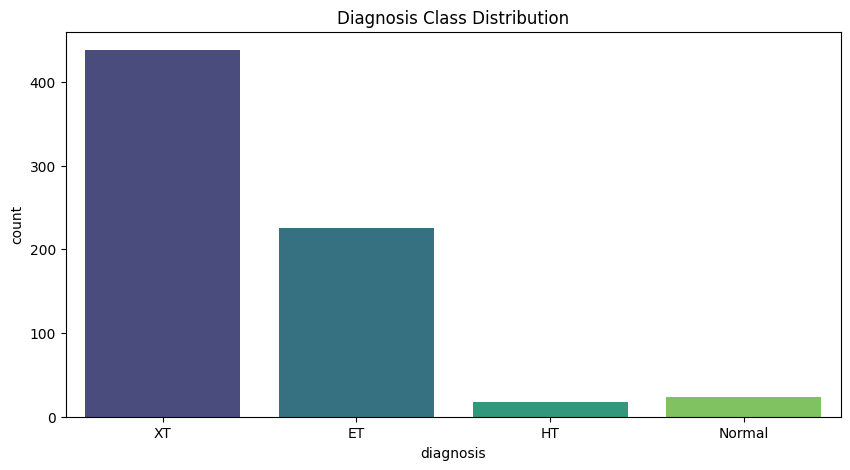

In [ ]:
def extract_diagnosis(text):
    if pd.isna(text): return 'Normal'
    text = str(text).upper()
    if 'XT' in text: return 'XT'
    if 'ET' in text: return 'ET'
    if 'HT' in text or 'HYPER' in text: return 'HT'
    return 'Normal'

def extract_pd(text):
    if pd.isna(text): return 0.0
    match = re.search(r'(\d+)', str(text))
    return float(match.group(1)) if match else 0.0

def assign_risk(row):
    pd_val = row['PCT/ MKT IN PD ']
    if pd.isna(pd_val) or pd_val == '':
        pd_val = row['extracted_pd']

    try: pd_val = float(pd_val)
    except: pd_val = 0.0

    if row['diagnosis'] == 'Normal': return 'normal'
    if pd_val < 20: return 'mild'
    if pd_val < 40: return 'moderate'
    return 'urgent'

df['diagnosis'] = df['Text in Image'].apply(extract_diagnosis)
df['extracted_pd'] = df['Text in Image'].apply(extract_pd)
df['risk'] = df.apply(assign_risk, axis=1)

print("Diagnosis Distribution:")
print(df['diagnosis'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.title('Diagnosis Class Distribution')
plt.show()

In [ ]:
IMG_SIZE = (224, 224)
label_map = {'Normal': 0, 'XT': 1, 'ET': 2, 'HT': 3}
IMG_DIR = '/content/drive/MyDrive/images/'
SAVE_DIR = '/content/drive/MyDrive/eye_dataset/'

def load_and_preprocess_image(filename):
    if pd.isna(filename) or str(filename).lower() == 'nan': return None
    # Cleaning filename: removing potential 'Embedded Index' prefix or spaces
    fname = str(filename).split(' ')[-1].strip()

    # Try a few common path variations
    paths_to_try = [
        os.path.join(IMG_DIR, fname),
        os.path.join(IMG_DIR, fname.lower()),
        os.path.join(IMG_DIR, fname + '.jpg'),
        os.path.join(IMG_DIR, fname + '.png')
    ]

    path = None
    for p in paths_to_try:
        if os.path.exists(p):
            path = p
            break

    if path is None: return None

    try:
        img = cv2.imread(path)
        if img is None: return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        return img / 255.0
    except Exception as e:
        return None

print(f'Searching for images in: {IMG_DIR}...')
X, y = [], []

# Ensure df exists in the local namespace
if 'df' in globals():
    for idx, row in df.iterrows():
        img = load_and_preprocess_image(row['Cropped Eye Image'])
        if img is not None:
            X.append(img)
            y.append(label_map[row['diagnosis']])

    X = np.array(X)
    y = np.array(y)

    if len(X) == 0:
        print('ERROR: 0 images loaded. Please verify that files exist in /content/drive/MyDrive/images/')
    else:
        print(f'Successfully loaded {len(X)} images.')
        plt.figure(figsize=(15, 6))
        for i in range(min(10, len(X))):
            plt.subplot(2, 5, i+1)
            plt.imshow(X[i])
            plt.title(list(label_map.keys())[y[i]])
            plt.axis('off')
        plt.show()
else:
    print('ERROR: DataFrame df not defined. Please run the CSV loading cells above.')

Searching for images in: /content/drive/MyDrive/images/...
ERROR: 0 images loaded. Please verify that files exist in /content/drive/MyDrive/images/


In [ ]:
if len(X) == 0:
    print("ERROR: Cannot augment data because 0 images were loaded. Please fix the image loading cell first.")
else:
    datagen = ImageDataGenerator(
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )

    # Augment to 200 per class
    target_count = 200
    X_aug, y_aug = [], []
    for label_name, label_idx in label_map.items():
        indices = np.where(y == label_idx)[0]
        class_imgs = X[indices]

        # Add original images
        X_aug.extend(class_imgs)
        y_aug.extend([label_idx]*len(class_imgs))

        needed = target_count - len(class_imgs)
        if needed > 0 and len(class_imgs) > 0:
            it = datagen.flow(class_imgs, batch_size=1)
            for _ in range(needed):
                X_aug.append(next(it)[0])
                y_aug.append(label_idx)

    X_aug, y_aug = np.array(X_aug), np.array(y_aug)

    X_train, X_temp, y_train, y_temp = train_test_split(X_aug, y_aug, test_size=0.3, stratify=y_aug, random_state=SEED)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

    print(f"Augmentation complete. Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

ERROR: Cannot augment data because 0 images were loaded. Please fix the image loading cell first.


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import os

# Ensure data exists before running
if 'X_train' not in globals():
    print("ERROR: X_train is not defined. Please ensure the Image Loading and Augmentation cells ran successfully.")
else:
    base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(4, activation='softmax')
    ])

    # Phase 1: Frozen Base
    model.compile(optimizer=optimizers.Adam(1e-4), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    ckpt_path = os.path.join(SAVE_DIR, 'best_model.h5')
    callbacks_list = [
        callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5),
        callbacks.ModelCheckpoint(ckpt_path, save_best_only=True)
    ]

    print("Starting Phase 1 Training...")
    hist1 = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=20, batch_size=32, callbacks=callbacks_list)

    # Phase 2: Fine Tuning
    base_model.trainable = True
    for layer in base_model.layers[:-30]: layer.trainable = False

    model.compile(optimizer=optimizers.Adam(1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    print("Starting Phase 2 Fine-Tuning...")
    hist2 = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=16, callbacks=callbacks_list)

ERROR: X_train is not defined. Please ensure the Image Loading and Augmentation cells ran successfully.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

if 'model' not in globals() or 'X_test' not in globals():
    print("ERROR: Model or test data not found. Please complete the training process first.")
else:
    y_pred = np.argmax(model.predict(X_test), axis=1)
    class_names = list(label_map.keys())

    print(classification_report(y_test, y_pred, target_names=class_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'))
    plt.show()

    # Combined curves
    if 'hist1' in globals() and 'hist2' in globals():
        acc = hist1.history['accuracy'] + hist2.history['accuracy']
        val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
        plt.figure(figsize=(10, 6))
        plt.plot(acc, label='Train Acc')
        plt.plot(val_acc, label='Val Acc')
        plt.axhline(y=0.85, color='r', linestyle='--', label='Target 85%')
        plt.legend()
        plt.title('Model Accuracy')
        plt.savefig(os.path.join(SAVE_DIR, 'accuracy_curve.png'))
        plt.show()

ERROR: Model or test data not found. Please complete the training process first.


In [ ]:
!pip install tensorflowjs

if 'model' not in globals():
    print("ERROR: 'model' is not defined. You must successfully complete the training process in cell 264a32a6 before exporting.")
else:
    # 1. H5
    model.save(os.path.join(SAVE_DIR, 'eye_model_final.h5'))

    # 2. TF.js
    import tensorflowjs as tfjs
    tfjs.converters.save_keras_model(model, os.path.join(SAVE_DIR, 'tfjs_model'))

    # 3. TFLite
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_model = converter.convert()
    with open(os.path.join(SAVE_DIR, 'eye_model.tflite'), 'wb') as f:
        f.write(tflite_model)

    # Metadata
    metadata = {
        "model_version": "1.0.0", "input_shape": [224, 224, 3],
        "classes": class_names if 'class_names' in globals() else [],
        "class_descriptions": {"Normal": "No strabismus", "XT": "Exotropia", "ET": "Esotropia", "HT": "Hypertropia"},
        "risk_mapping": {"Normal": "normal", "XT": "moderate", "ET": "moderate", "HT": "mild"},
        "pd_thresholds": { "mild": 20, "moderate": 40, "urgent": 40 }
    }
    with open(os.path.join(SAVE_DIR, 'model_metadata.json'), 'w') as f:
        json.dump(metadata, f, indent=2)

ERROR: 'model' is not defined. You must successfully complete the training process in cell 264a32a6 before exporting.


In [ ]:
def predict_eye_image(image_path):
    if not os.path.exists(image_path):
        return None
    img = cv2.imread(image_path)
    if img is None: return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224)) / 255.0

    preds = model.predict(np.expand_dims(img_resized, axis=0))[0]
    idx = np.argmax(preds)
    condition = class_names[idx]

    return {
        "condition": condition,
        "confidence": float(preds[idx]),
        "all_scores": {class_names[i]: float(preds[i]) for i in range(4)}
    }

# Run demo on first 3 available images
if 'df' in globals() and 'IMG_DIR' in globals():
    count = 0
    for i in range(len(df)):
        if count >= 3: break
        raw_val = df.iloc[i]['Cropped Eye Image']
        if pd.isna(raw_val): continue
        fname = str(raw_val).split(' ')[-1]
        path = os.path.join(IMG_DIR, fname)
        if os.path.exists(path):
            res = predict_eye_image(path)
            if res:
                print(f"Prediction for {fname}: {res['condition']} ({res['confidence']:.2f})")
                count += 1
else:
    print("Environment variables 'df' or 'IMG_DIR' not found. Ensure all previous cells have been executed.")

### FastAPI Backend & React Frontend Snippets
The following cell contains the code snippets for deployment.

In [ ]:
fastapi_code = """
@app.post("/ai/analyze-eye")
async def analyze_eye(data: dict):
    image_data = base64.b64decode(data['image'])
    nparr = np.frombuffer(image_data, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    # Preprocess and model.predict here...
    return JSONResponse(content=result)
"""

react_code = """
export const analyzeEyeImage = async (canvas: HTMLCanvasElement) => {
  const model = await tf.loadLayersModel('/models/tfjs_model/model.json');
  const tensor = tf.browser.fromPixels(canvas).resizeNearestNeighbor([224, 224]).div(255).expandDims();
  const prediction = await model.predict(tensor) as tf.Tensor;
  // process results...
};
"""

print("FastAPI Snippet:\n", fastapi_code)
print("\nReact Snippet:\n", react_code)

FastAPI Snippet:
 
@app.post("/ai/analyze-eye")
async def analyze_eye(data: dict):
    image_data = base64.b64decode(data['image'])
    nparr = np.frombuffer(image_data, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    # Preprocess and model.predict here...
    return JSONResponse(content=result)


React Snippet:
 
export const analyzeEyeImage = async (canvas: HTMLCanvasElement) => {
  const model = await tf.loadLayersModel('/models/tfjs_model/model.json');
  const tensor = tf.browser.fromPixels(canvas).resizeNearestNeighbor([224, 224]).div(255).expandDims();
  const prediction = await model.predict(tensor) as tf.Tensor;
  // process results...
};

